# Tebas Fairplay Report (Fantasy S2)

In [1]:
import numpy as np
import pandas as pd

trading_df = pd.read_csv('../data/trading.csv')
trading_df['date'] = pd.to_datetime(trading_df['date']).dt.date
trading_df.head(10)

,date,type,team1,team2,player,amount
0,2026-04-02,purchased,La rataneta,JMjugon,Sow,7000000
1,2026-04-02,purchased,cristian.ayala12,LALIGA,Sorloth,15856606
2,2026-04-02,sold,-papi—,LALIGA,A. Batalla,5372461
3,2026-04-02,sold,-papi—,LALIGA,Ivan Martin,2092885
4,2026-04-02,sold,Ramonaco FC,LALIGA,Carvajal,2498436
5,2026-04-02,sold,Ramonaco FC,LALIGA,Muriqi,59291346
6,2026-04-01,purchased,LamineTheTuareg,LILTEAM,Urko,2500001
7,2026-04-01,sold,PlatanosVerdes,LALIGA,R.P. Bigas,1051585
8,2026-04-01,purchased,tete alejo,JMjugon,R. Araujo,4500000
9,2026-04-01,purchased,tete alejo,cristian.ayala12,Fran Garcia,4000000


In [2]:
assert not(trading_df['date'].diff().dropna().dt.days > 0).any()

## Transactions

### All transactions plot

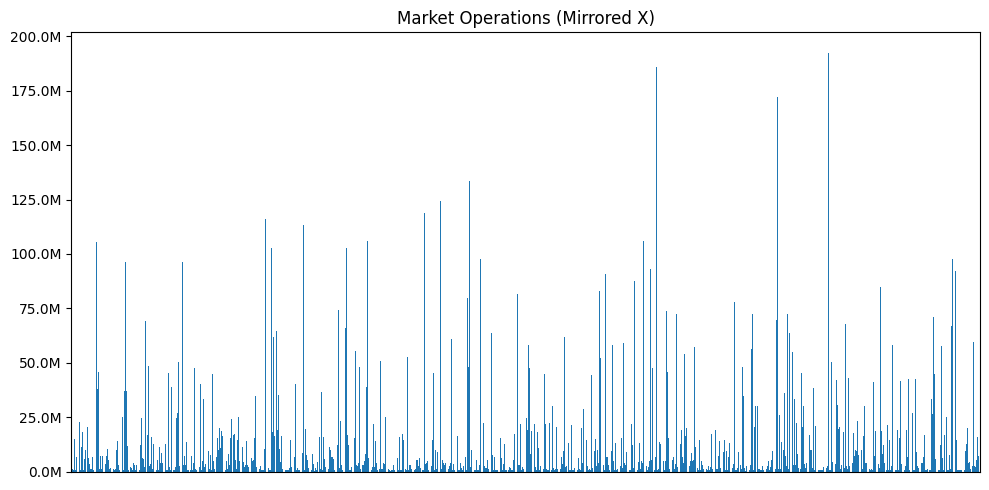

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10,5))

ax.bar(trading_df.index, trading_df['amount'])

# Invertir eix X
off = 1
ax.set_xlim(-off, len(trading_df) - off)
ax.invert_xaxis()

# Format milions
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
ax.yaxis.set_major_formatter(formatter)

plt.title('Market Operations (Mirrored X)')
plt.xticks([])

plt.tight_layout()
plt.show()

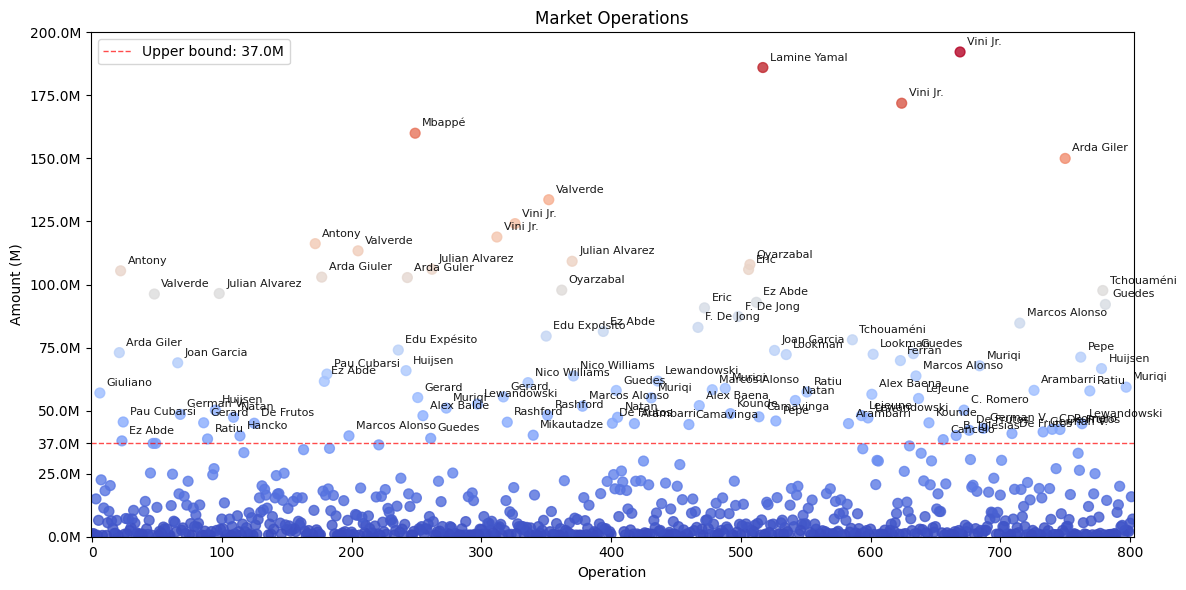

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

amounts = trading_df['amount'].values
n = len(amounts)

# Reversed positions: first record on the right, last on the left
x_plot = np.arange(n - 1, -1, -1)

# Scatter plot with color gradient: blue (cheap) -> red (expensive)
norm = plt.Normalize(vmin=amounts.min(), vmax=amounts.max())
sc = ax.scatter(x_plot, amounts, c=amounts, cmap='coolwarm', alpha=0.8, s=50, norm=norm)

# Detect outliers using IQR
Q1 = np.percentile(amounts, 25)
Q3 = np.percentile(amounts, 75)
IQR = Q3 - Q1
lower_bound = 0 #Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Draw upper bound line
ax.axhline(y=upper_bound, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'Upper bound: {upper_bound/1e6:.1f}M')
ax.legend()

outliers_mask = (amounts < lower_bound) | (amounts > upper_bound)

# Label outliers with player names
players = trading_df['player'].values
for i, (is_outlier, amount, player) in enumerate(zip(outliers_mask, amounts, players)):
    if is_outlier:
        ax.annotate(
            player,
            (x_plot[i], amount),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            alpha=0.9
        )

# X axis: 0 on the left, max on the right
ax.set_xlim(-1, n)
ax.set_ylim(0, amounts.max())

# Format millions
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
ax.yaxis.set_major_formatter(formatter)

# Add upper_bound to Y axis ticks
current_ticks = list(ax.get_yticks())
current_ticks.append(upper_bound)
ax.set_yticks(sorted(current_ticks))

plt.title('Market Operations')
plt.xlabel('Operation')
plt.ylabel('Amount (M)')

plt.tight_layout()
plt.show()

### Top transactions

In [5]:
trading_df.sort_values('amount', ascending=False).head(15)

,date,type,team1,team2,player,amount
133,2026-03-17,sold,Ramonaco FC,LALIGA,Vini Jr.,192220472
285,2026-03-02,purchased,La rataneta,LALIGA,Lamine Yamal,186047732
178,2026-03-11,purchased,Ramonaco FC,LALIGA,Vini Jr.,171892491
553,2026-02-03,purchased,LILTEAM,LALIGA,Mbappé,160000000
52,2026-03-25,purchased,Ramonaco FC,LALIGA,Arda Giler,149999999
450,2026-02-13,sold,cristian.ayala12,LALIGA,Valverde,133631252
476,2026-02-11,sold,Millou912,LALIGA,Vini Jr.,124154664
490,2026-02-10,purchased,Millou912,LALIGA,Vini Jr.,118836312
630,2026-01-27,sold,LILTEAM,LALIGA,Antony,116209495
597,2026-01-30,purchased,cristian.ayala12,Ramonaco FC,Valverde,113368973


### Daily stats

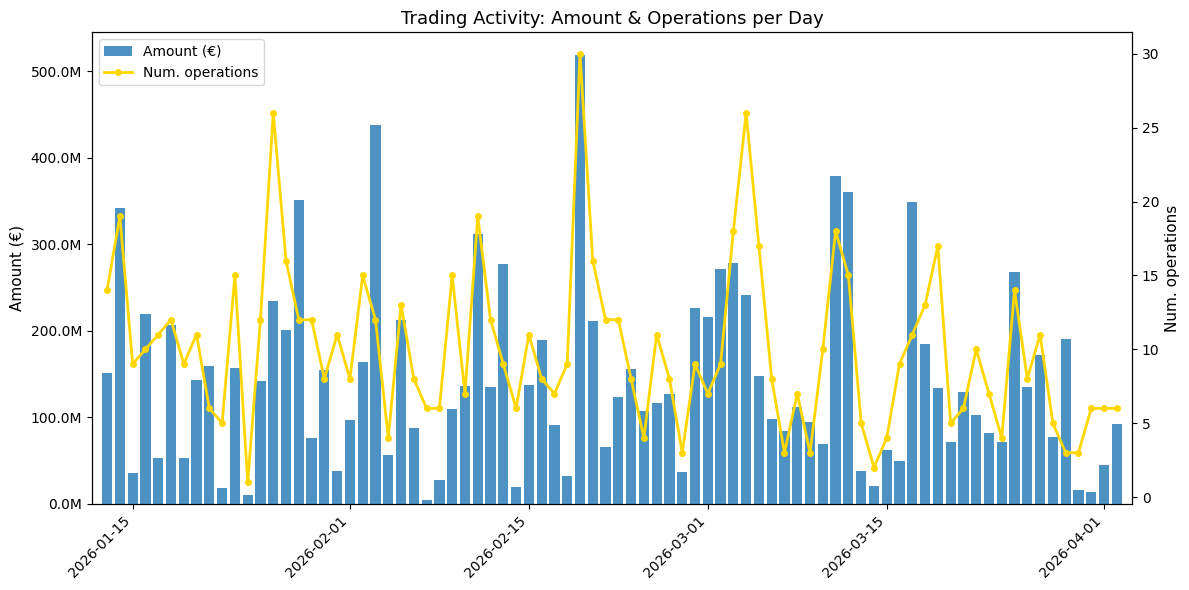

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import datetime

# --- Aggregation ---
date_groups = trading_df.groupby('date')

daily_amount = date_groups['amount'].sum()
daily_counts = trading_df['date'].value_counts()

# Full date range
full_range = pd.date_range(trading_df['date'].min(), trading_df['date'].max())

daily_amount = daily_amount.reindex(full_range, fill_value=0)
daily_counts = daily_counts.reindex(full_range, fill_value=0)

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(12,6))

# Bars (amount)
bars = ax1.bar(
    daily_amount.index,
    daily_amount,
    width=0.8,
    alpha=0.8,
    label='Amount (€)'
)

ax1.set_ylabel('Amount (€)', fontsize=11)

# Format Y axis in millions
ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

# Line (counts)
ax2 = ax1.twinx()
ax2.plot(
    daily_counts.index,
    daily_counts,
    marker='o',
    color='gold',
    linewidth=2,
    markersize=4,
    label='Num. operations'
)

ax2.set_ylabel('Num. operations', fontsize=11)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper left'
)

# --- X axis formatting (KEY PART) ---
ax1.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=8))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment('right')

# --- Baseline ---
ax1.axhline(0, linewidth=0.6, color='black', alpha=0.6)

# --- Margins ---
ax1.margins(x=0.01)

# --- Title ---
plt.title('Trading Activity: Amount & Operations per Day', fontsize=13)

# --- Layout ---
plt.tight_layout()

plt.show()

#### Top days with more amount

In [7]:
dd = daily_amount.sort_values(ascending=False)
display(dd)
date_groups.get_group(dd.index[0].date())

2026-02-19    518762461
2026-02-03    437345511
2026-03-11    378578788
2026-03-12    360767106
2026-01-28    350817669
                ...    
2026-01-22     18393833
2026-03-30     15864971
2026-03-31     14075415
2026-01-24      9500000
2026-02-07      4014859
Name: amount, Length: 80, dtype: int64

,date,type,team1,team2,player,amount
379,2026-02-19,sold,LILTEAM,LALIGA,Cancelo,22203918
380,2026-02-19,sold,-papi—,LALIGA,A. Abqar,639349
381,2026-02-19,sold,-papi—,LALIGA,Chimy Avila,562359
382,2026-02-19,purchased,-papi—,JMjugon,M. Roman,1100069
383,2026-02-19,purchased,tete alejo,-papi—,Alvaro Garcia,22000000
384,2026-02-19,purchased,tete alejo,Millou912,Arambarri,44862050
385,2026-02-19,purchased,cristian.ayala12,tete alejo,Pol Lozano,1000000
386,2026-02-19,purchased,JMjugon,LALIGA,Raul Moro,9300069
387,2026-02-19,purchased,La rataneta,LALIGA,Obed Vargas,2694485
388,2026-02-19,purchased,Millou912,LALIGA,Dimitrievski,617763


#### Top days with more operations

In [8]:
dd = daily_counts.sort_values(ascending=False)
display(dd)
date_groups.get_group(dd.index[0].date())

2026-02-19    30
2026-01-26    26
2026-03-04    26
2026-01-14    19
2026-02-11    19
              ..
2026-03-07     3
2026-03-30     3
2026-03-09     3
2026-03-14     2
2026-01-24     1
Name: count, Length: 80, dtype: int64

,date,type,team1,team2,player,amount
379,2026-02-19,sold,LILTEAM,LALIGA,Cancelo,22203918
380,2026-02-19,sold,-papi—,LALIGA,A. Abqar,639349
381,2026-02-19,sold,-papi—,LALIGA,Chimy Avila,562359
382,2026-02-19,purchased,-papi—,JMjugon,M. Roman,1100069
383,2026-02-19,purchased,tete alejo,-papi—,Alvaro Garcia,22000000
384,2026-02-19,purchased,tete alejo,Millou912,Arambarri,44862050
385,2026-02-19,purchased,cristian.ayala12,tete alejo,Pol Lozano,1000000
386,2026-02-19,purchased,JMjugon,LALIGA,Raul Moro,9300069
387,2026-02-19,purchased,La rataneta,LALIGA,Obed Vargas,2694485
388,2026-02-19,purchased,Millou912,LALIGA,Dimitrievski,617763


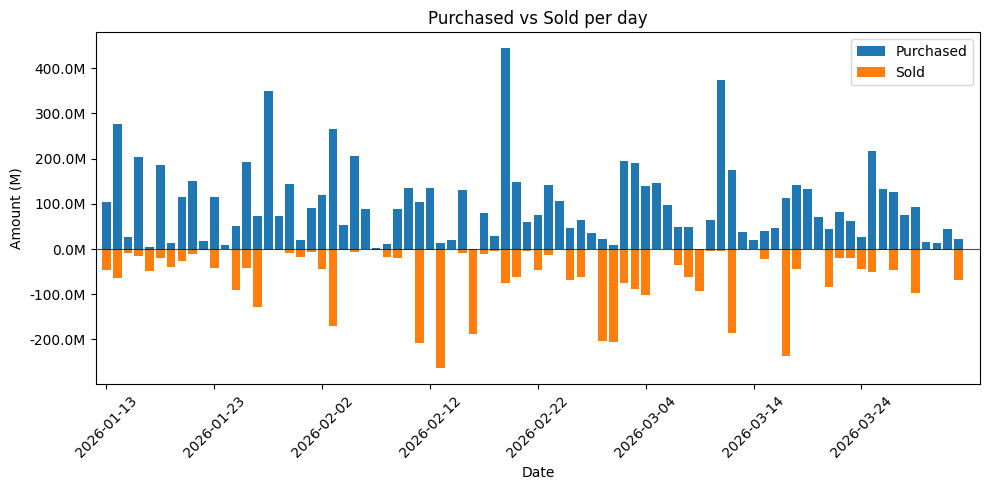

In [9]:
full_range = pd.date_range(trading_df['date'].min(), trading_df['date'].max())

daily = trading_df.groupby(['date', 'type'])['amount'].sum().unstack(fill_value=0)
daily = daily.reindex(full_range, fill_value=0)
daily = daily.reindex(columns=['purchased', 'sold'], fill_value=0)

plt.figure(figsize=(10,5))

# Purchased (positive)
x = np.arange(len(daily))
plt.bar(x, daily['purchased'], label='Purchased')
plt.bar(x, -daily['sold'], label='Sold')

plt.xticks(x, daily.index.strftime('%Y-%m-%d'), rotation=45)

plt.title('Purchased vs Sold per day')
plt.xlim(-1, len(x)+1)
plt.xlabel('Date')
plt.ylabel('Amount (M)')

step= 10
plt.gca().yaxis.set_major_formatter(formatter)
plt.xticks(x[::step], daily.index.strftime('%Y-%m-%d')[::step], rotation=45)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
daily['diff'] = daily['sold'] - daily['purchased']
daily

type,purchased,sold,diff
2026-01-13,104276294,46271593,-58004701
2026-01-14,277528645,63748033,-213780612
2026-01-15,26750001,8431704,-18318297
2026-01-16,203500840,15240395,-188260445
2026-01-17,4221331,48762351,44541020
...,...,...,...
2026-03-29,92850727,97629095,4778368
2026-03-30,15864971,0,-15864971
2026-03-31,12424319,1651096,-10773223
2026-04-01,43668739,1051585,-42617154


## Teams

The team with the most operations

In [11]:
trading_df['team1'].value_counts()

team1
-papi—              113
Ramonaco FC         108
cristian.ayala12     82
La rataneta          72
JMjugon              70
LamineTheTuareg      68
Millou912            68
PlatanosVerdes       50
LILTEAM              48
La Agustineta 96     45
PavelmacuFC          42
tete alejo           37
Name: count, dtype: int64

The most scouted team

In [42]:
bbt = trading_df['team2'].value_counts()
bbt

team2
LALIGA              549
La rataneta          38
Millou912            28
Ramonaco FC          26
LamineTheTuareg      23
cristian.ayala12     21
tete alejo           20
-papi—               20
PavelmacuFC          18
JMjugon              17
LILTEAM              17
PlatanosVerdes       15
La Agustineta 96     11
Name: count, dtype: int64

### The Black Beast Teams

In [45]:
bbt_group = trading_df.groupby('team2')

for team in bbt.index[1:]:
    print(f'--- {team} ---')
    display(bbt_group.get_group(team)['team1'].value_counts())
    print()




--- La rataneta ---


team1
-papi—              7
PlatanosVerdes      5
LamineTheTuareg     5
Ramonaco FC         4
La Agustineta 96    4
cristian.ayala12    3
Millou912           3
tete alejo          2
LILTEAM             2
PavelmacuFC         2
JMjugon             1
Name: count, dtype: int64


--- Millou912 ---


team1
La rataneta         7
PlatanosVerdes      4
Ramonaco FC         4
-papi—              3
JMjugon             2
cristian.ayala12    2
LamineTheTuareg     2
LILTEAM             2
tete alejo          1
PavelmacuFC         1
Name: count, dtype: int64


--- Ramonaco FC ---


...

team1
-papi—              4
La rataneta         4
LamineTheTuareg     3
Ramonaco FC         3
La Agustineta 96    2
PavelmacuFC         1
Name: count, dtype: int64


--- PlatanosVerdes ---


team1
La Agustineta 96    4
LamineTheTuareg     2
-papi—              2
Ramonaco FC         2
La rataneta         2
cristian.ayala12    1
Millou912           1
JMjugon             1
Name: count, dtype: int64


--- La Agustineta 96 ---


team1
-papi—            3
PavelmacuFC       3
La rataneta       2
PlatanosVerdes    2
LILTEAM           1
Name: count, dtype: int64

In [ ]:

display(get_black_beast_teams('La rataneta'))


team1
-papi—              7
PlatanosVerdes      5
LamineTheTuareg     5
Ramonaco FC         4
La Agustineta 96    4
cristian.ayala12    3
Millou912           3
tete alejo          2
LILTEAM             2
PavelmacuFC         2
JMjugon             1
Name: count, dtype: int64

In [40]:
qq.index[1:]

Index(['La rataneta', 'Millou912', 'Ramonaco FC', 'LamineTheTuareg',
       'cristian.ayala12', 'tete alejo', '-papi—', 'PavelmacuFC', 'JMjugon',
       'LILTEAM', 'PlatanosVerdes', 'La Agustineta 96'],
      dtype='str', name='team2')

## Fairplay

In [13]:
print(trading_df['player'].value_counts().head(15))

player
Alvaro Garcia    9
Sorloth          6
Witsel           6
Ugrinic          6
De Galarreta     6
Victor Mufoz     6
Cardona          6
Muriqi           5
Darder           5
Yuri             5
Guedes           5
Brahim           5
Griezmann        5
De Frutos        5
A. Valles        5
Name: count, dtype: int64


In [14]:
trading_df['fp'] = np.nan
for player, group_df in trading_df.groupby('player'):
    fp = group_df['date'].iloc[::-1].diff()
    if len(fp) > 1:
        for idx, value in fp.items():
            row = trading_df.loc[idx]
            trading_df.at[idx, 'fp'] = float(value.days)

trading_df

,date,type,team1,team2,player,amount,fp
0,2026-04-02,purchased,La rataneta,JMjugon,Sow,7000000,14.0
1,2026-04-02,purchased,cristian.ayala12,LALIGA,Sorloth,15856606,10.0
2,2026-04-02,sold,-papi—,LALIGA,A. Batalla,5372461,12.0
3,2026-04-02,sold,-papi—,LALIGA,Ivan Martin,2092885,NaN
4,2026-04-02,sold,Ramonaco FC,LALIGA,Carvajal,2498436,27.0
...,...,...,...,...,...,...,...
798,2026-01-13,purchased,La rataneta,LALIGA,Vilaplana,584831,NaN
799,2026-01-13,purchased,La Agustineta 96,LALIGA,David Soria,15000000,NaN
800,2026-01-13,purchased,La rataneta,LALIGA,Marc Bernal,710000,NaN
801,2026-01-13,purchased,Ramonaco FC,LALIGA,Kiko F.,1251000,NaN


In [15]:
trading_df[~trading_df['fp'].isnull()]

,date,type,team1,team2,player,amount,fp
0,2026-04-02,purchased,La rataneta,JMjugon,Sow,7000000,14.0
1,2026-04-02,purchased,cristian.ayala12,LALIGA,Sorloth,15856606,10.0
2,2026-04-02,sold,-papi—,LALIGA,A. Batalla,5372461,12.0
4,2026-04-02,sold,Ramonaco FC,LALIGA,Carvajal,2498436,27.0
5,2026-04-02,sold,Ramonaco FC,LALIGA,Muriqi,59291346,15.0
...,...,...,...,...,...,...,...
709,2026-01-20,sold,JMjugon,LALIGA,Alvaro Nufiez,24555404,4.0
718,2026-01-20,purchased,JMjugon,LALIGA,Alvaro Garcia,581988,2.0
724,2026-01-19,sold,-papi—,LALIGA,A. Batalla,11375056,1.0
725,2026-01-19,sold,-papi—,LALIGA,Stuani,589292,5.0


In [16]:
mask_purchased = (trading_df['type'] == 'purchased') & (trading_df['team2'] != 'LALIGA')
mask_sold = (trading_df['type'] == 'sold')

targets = trading_df[mask_purchased | mask_sold]
display(targets)
targets['team1'].value_counts()

,date,type,team1,team2,player,amount,fp
0,2026-04-02,purchased,La rataneta,JMjugon,Sow,7000000,14.0
2,2026-04-02,sold,-papi—,LALIGA,A. Batalla,5372461,12.0
3,2026-04-02,sold,-papi—,LALIGA,Ivan Martin,2092885,NaN
4,2026-04-02,sold,Ramonaco FC,LALIGA,Carvajal,2498436,27.0
5,2026-04-02,sold,Ramonaco FC,LALIGA,Muriqi,59291346,15.0
...,...,...,...,...,...,...,...
790,2026-01-13,sold,LILTEAM,LALIGA,Puado,5542618,NaN
791,2026-01-13,sold,-papi—,LALIGA,D. Martinez,503413,NaN
792,2026-01-13,sold,-papi—,LALIGA,Vargas,18236496,NaN
793,2026-01-13,sold,-papi—,LALIGA,Laporte,11400818,NaN


team1
-papi—              94
Ramonaco FC         65
cristian.ayala12    49
La rataneta         47
Millou912           44
LamineTheTuareg     42
JMjugon             36
PlatanosVerdes      34
La Agustineta 96    30
LILTEAM             29
tete alejo          24
PavelmacuFC         21
Name: count, dtype: int64

In [17]:
def player_tracker(player_name):
    gg = trading_df.groupby('player')
    player = gg.get_group(player_name)
    display(player)

## Last 5 days operations

In [18]:
targets[targets['fp'] == 5]

,date,type,team1,team2,player,amount,fp
56,2026-03-25,sold,cristian.ayala12,LALIGA,De Frutos,42512052,5.0
72,2026-03-23,sold,Ramonaco FC,LALIGA,Sorloth,19130504,5.0
144,2026-03-15,sold,-papi—,LALIGA,Oblak,20946467,5.0
165,2026-03-12,sold,La rataneta,LALIGA,Lejeune,54819768,5.0
202,2026-03-08,sold,-papi—,LALIGA,Bellerin,3009073,5.0
220,2026-03-05,purchased,LILTEAM,La rataneta,Kubo,12869000,5.0
250,2026-03-04,sold,tete alejo,LALIGA,Pere Milla,11298289,5.0
282,2026-03-02,sold,-papi—,LALIGA,Griezmann,13665151,5.0
304,2026-02-28,sold,Ramonaco FC,LALIGA,F. De Jong,87326198,5.0
315,2026-02-26,sold,Ramonaco FC,LALIGA,Lucas Beltran,1393392,5.0


In [20]:
#player_tracker('Stuani')
#player_tracker('Aramburu')
#player_tracker('Oluwaseyi')
#player_tracker('Lucas Beltran')
#player_tracker('F. De Jong')
#player_tracker('Griezmann')
#player_tracker('Pere Milla')
#player_tracker('Kubo')
#player_tracker('Bellerin')
#player_tracker('Lejeune')
#player_tracker('Oblak')
#player_tracker('Sorloth')
#player_tracker('De Frutos')


#### 5-day movements studied

| Team1             | Team2         | player        | dates                     | profit            | Observations              |
| ---------         | ---------     | ------------- | ------------------------  | -------------     | -----------------------   |
| papi              | LaLiga        | Stuani        | 2026-01-14 / 2026-01-19	| -410,708€         | -                         |
| Ramonaco FC	    | PavelmacuFC   | Aramburu      | 2026-01-18 / 2026-01-23   | -100€             | -                         |
| cristian.ayala12  | LaLiga        | Oluwaseyi     | 2026-02-14 / 2026-02-19   | -69,449€          | -                         |
| Ramonaco FC       | LaLiga        | Lucas Beltran | 2026-02-21 / 2026-02-26   | -341,608€         | -                         |
| Ramonaco FC       | LaLiga        | F. De Jong    | 2026-02-23 / 2026-02-28   | 4,326,199€        | -                         |
| papi              | JMjugon       | Griezmann     | 2026-02-25 / 2026-03-02   | -1,729,270€       | -                         |
| tete alejo	    | LALIGA        | Pere Milla    | 2026-02-27 / 2026-03-04   | -1,108,271€       | -                         |
| LILTEAM           | La rataneta   | Kubo          | 2026-02-28 / 2026-03-05   | -869€             | -                         |
| papi              | LaLiga        | Bellerin      | 2026-03-03 / 2026-03-08   | -1,990,927€       | -                         |
| La rataneta       | LaLiga        | Lejeune       | 2026-03-07 / 2026-03-12   | 6,802,245€        | -                         |
| papi              | LaLiga        | Oblak         | 2026-03-10 / 2026-03-15   | -9,053,533€       | Injured                   |
| Ramonaco FC       | LaLiga        | Sorloth       | 2026-03-18 / 2026-03-23   | 1,464,952€        | -                         |
| cristian.ayala12  | LaLiga        | De Frutos     | 2026-03-20 / 2026-03-25   | 1,601,364€        | -                         |




## Last 4 days operations

In [21]:
targets[targets['fp'] == 4]

,date,type,team1,team2,player,amount,fp
203,2026-03-08,sold,-papi—,LALIGA,Dela,790170,4.0
207,2026-03-08,sold,-papi—,LALIGA,Bryan Gil,1704569,4.0
296,2026-02-28,sold,La rataneta,LALIGA,Eric,105949920,4.0
338,2026-02-23,sold,La rataneta,LALIGA,Obed Vargas,2422126,4.0
393,2026-02-19,sold,cristian.ayala12,LALIGA,Etta Eyong,21713369,4.0
431,2026-02-16,sold,Ramonaco FC,LALIGA,Nico Williams,63744848,4.0
511,2026-02-09,sold,Ramonaco FC,LALIGA,Pedrosa,631000,4.0
578,2026-02-01,sold,JMjugon,LALIGA,Bryan,5777251,4.0
592,2026-01-31,purchased,JMjugon,LamineTheTuareg,Ilaix Moriba,1550069,4.0
641,2026-01-27,purchased,-papi—,Ramonaco FC,lago Aspas,5500000,4.0


In [22]:
#player_tracker('Alvaro Nufiez')
#player_tracker('O. Sancet')
#player_tracker('lago Aspas')
#player_tracker('Ilaix Moriba')
#player_tracker('Bryan')
#player_tracker('Pedrosa')
#player_tracker('Nico Williams')
#player_tracker('Etta Eyong')
#player_tracker('Obed Vargas')
#player_tracker('Eric')
#player_tracker('Bryan Gil')
#player_tracker('Dela')


#### 4-day movements studied

| Team1             | Team2     | player        | dates                     | profit            | Observations              |
| ---------         | --------- | ------------- | ------------------------  | -------------     | -----------------------   |
| JMjugon           | LaLiga    | Alvaro Nuñez  | 2026-01-16 / 2026-01-20	| -12,444,665€      | Alvaro Nuñez got injured  |
| Ramonaco FC       | LaLiga    | O. Sancet     | 2026-01-22 / 2026-01-26	| -2,066,332€       | -                         |
| Ramonaco FC       | LaLiga    | lago Aspas    | 2026-01-23 / 2026-01-27   | -2,812,000€       | -                         |
| LamineTheTuareg   | JMjugon   | Ilaix Moriba  | 2026-01-27 / 2026-01-31   | -286,879€         | -                         |
| JMjugon           | LaLiga    | Bryan         | 2026-01-28 / 2026-02-01   | -10,618,870€      | Bryan was transferred to the Premier League |
| Ramonaco FC       | LaLiga    | Pedrosa       | 2026-02-05 / 2026-02-09	| **37,743€**       | -                         |
| Ramonaco FC       | LaLiga    | Nico Williams | 2026-02-12 / 2026-02-16   | **2,644,848€**    | -                         |
| cristian.ayala12  | LaLiga    | Etta Eyong    | 2026-02-15 / 2026-02-19   | -506,631€         | -                         |
| La rataneta       | LaLiga    | Obed Vargas   | 2026-02-19 / 2026-02-23   | -272,359€         | -                         |
| La rataneta       | LaLiga    | Eric          | 2026-02-24 / 2026-02-28   | **15,196,139€**   | -                         |
| papi              | LaLiga    | Bryan Gil     | 2026-03-04 / 2026-03-08   | -3,395,431€       | -                         |
| papi              | LaLiga    | Dela          | 2026-03-04 / 2026-03-08   | -2,209,830€       | -                         |




## Last 3 days operations

In [23]:
targets[targets['fp'] == 3]

,date,type,team1,team2,player,amount,fp
170,2026-03-11,sold,Millou912,LALIGA,Raillo,2435323,3.0
309,2026-02-26,sold,JMjugon,LALIGA,Peque,655841,3.0
656,2026-01-26,sold,-papi—,LALIGA,Molina,1118262,3.0
687,2026-01-23,sold,JMjugon,LALIGA,Salinas,597537,3.0
747,2026-01-17,sold,-papi—,LALIGA,R. Araujo,3830807,3.0


In [24]:
#player_tracker('R. Araujo')
#player_tracker('Salinas')
#player_tracker('Molina')
#player_tracker('Peque')
#player_tracker('Raillo')


#### 3-day movements studied

| Team1             | Team2     | player        | dates                     | profit            | Observations              |
| ---------         | --------- | ------------- | ------------------------  | -------------     | -----------------------   |
| papi              | LaLiga    | R. Araujo     | 2026-01-14 / 2026-01-17	| -3,169,193€       | -                         |
| JMjugon           | LaLiga    | Salinas       | 2026-01-20 / 2026-01-23   | **3,874€**        | -                         |
| papi              | LaLiga    | Molina        | 2026-01-23 / 2026-01-26   | -881,738€         | -                         |
| JMjugon           | LaLiga    | Peque         | 2026-02-23 / 2026-02-26   | -144,159€         | -                         |
| Millou912         | LaLiga    | Raillo        | 2026-03-08 / 2026-03-11   | -14,426€          | -                         |






## Last 2 days operations

In [25]:
targets[targets['fp'] == 2]

,date,type,team1,team2,player,amount,fp
378,2026-02-20,sold,cristian.ayala12,LALIGA,Almeida,731116,2.0
451,2026-02-13,sold,Ramonaco FC,LALIGA,Rashford,48187028,2.0
458,2026-02-13,purchased,PavelmacuFC,Millou912,Leo Roman,4000000,2.0
697,2026-01-22,sold,JMjugon,LALIGA,Trejo,599367,2.0
698,2026-01-22,sold,JMjugon,LALIGA,Alvaro Garcia,619818,2.0


In [26]:
#player_tracker('Alvaro Garcia')
#player_tracker('Trejo')
#player_tracker('Leo Roman')
#player_tracker('Rashford')
#player_tracker('Almeida')


#### 2-day movements studied

| Team1             | Team2     | player        | dates                     | profit            | Observations              |
| ---------         | --------- | ------------- | ------------------------  | -------------     | -----------------------   |
| JMjugon           | LaLiga    | Alvaro Garcia | 2026-01-20 / 2026-01-22   | **37,830€**       | -                         |
| JMjugon           | LaLiga    | Trejo         | 2026-01-20 / 2026-01-22   | **40€**           | -                         |
| PavelmacuFC       | Millou912 | Leo Roman     | 2026-02-11 / 2026-02-13   | **823,860€**      | -                         |
| Ramonaco FC       | LaLiga    | Rashford      | 2026-02-11 / 2026-02-13   | **2,771,611€**    | -                         |
| cristian.ayala12  | LaLiga    | Almeida       | 2026-02-18 / 2026-02-20   | **45,596€**       | -                         |






## Last 1 days operations

In [27]:
targets[targets['fp'] == 1]

,date,type,team1,team2,player,amount,fp
212,2026-03-06,purchased,tete alejo,cristian.ayala12,De Galarreta,9110000,1.0
364,2026-02-20,purchased,LILTEAM,Millou912,Dimitrievski,2500000,1.0
476,2026-02-11,sold,Millou912,LALIGA,Vini Jr.,124154664,1.0
631,2026-01-27,sold,-papi—,LALIGA,Carlos V.,10458503,1.0
724,2026-01-19,sold,-papi—,LALIGA,A. Batalla,11375056,1.0


In [28]:
#player_tracker('A. Batalla')
#player_tracker('Carlos V.')
#player_tracker('Vini Jr.')
#player_tracker('Dimitrievski')
#player_tracker('De Galarreta')


#### 1-day movements studied

| Team1             | Team2     | player        | dates                     | profit            | Observations              |
| ---------         | --------- | ------------- | ------------------------  | -------------     | -----------------------   |
| papi              | LaLiga    | A. Batalla    | 2026-01-18 / 2026-01-19   | -5,624,944€       | -                         |
| papi              | LaLiga    | Carlos V.     | 2026-01-26 / 2026-01-27   | -5,036,540€       | -                         |
| Millou912         | LaLiga    | Vini Jr.      | 2026-02-10 / 2026-02-11   | **5,318,352€**    | -                         |
| LILTEAM           | Millou912 | Dimitrievski  | 2026-02-19 / 2026-02-20   | **1,882,237€**    | -                         |
| tete alejo        | cristian.ayala12 | De Galarreta | 2026-03-05 / 2026-03-06 | 0€            | -                         |






## Last 0 days operations

In [29]:
targets[targets['fp'] == 0]

,date,type,team1,team2,player,amount,fp
